# Plotting sandbox

This notebook recreates the paper-style grouped bar plot for the three saved benchmark runs you asked to compare:

- `offline_dtw_paper_numba`
- `oltw_paper_test`
- `oltw_global_paper_test`

The original paper's Figure 2 uses grouped bars over discrete tolerance values. Here, the same plot grammar is applied to your three saved tolerance-curve CSVs.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

EXPERIMENTS = {
    "offline_dtw_paper_numba": {
        "label": "DTW",
        "path": METRICS_DIR / "offline_dtw_paper_numba_tolerance_curve.csv",
        "color": "#4C78A8",
    },
    "oltw_paper_test": {
        "label": "OLTW",
        "path": METRICS_DIR / "oltw_paper_test_tolerance_curve.csv",
        "color": "#F58518",
    }
    # "oltw_global_paper_test": {
    #     "label": "OLTW-global",
    #     "path": METRICS_DIR / "oltw_global_paper_test_tolerance_curve.csv",
    #     "color": "#54A24B",
    # },
}

TOLERANCES_MS = [10, 20, 50, 100, 200, 500]
OUTPUT_FIGURE = FIGURES_DIR / "paper_style_method_comparison.png"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": True,
        "axes.spines.right": True,
        "font.size": 11,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
    }
)

missing_paths = [meta["path"] for meta in EXPERIMENTS.values() if not meta["path"].exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing tolerance-curve CSVs: {missing_paths}")

METRICS_DIR, FIGURES_DIR

(PosixPath('/home/diego/School/SP26/E207_project/outputs/metrics'),
 PosixPath('/home/diego/School/SP26/E207_project/outputs/figures'))

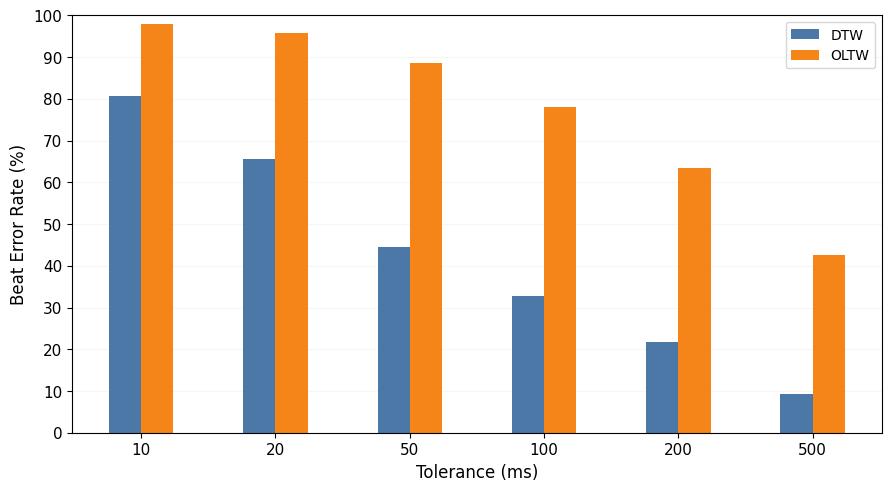

Saved figure to: /home/diego/School/SP26/E207_project/outputs/figures/paper_style_method_comparison.png


,experiment_name,display_name,num_predictions
0,offline_dtw_paper_numba,DTW,5253894
1,oltw_paper_test,OLTW,5250206


In [15]:
records = []
prediction_counts = []

for experiment_name, meta in EXPERIMENTS.items():
    frame = pd.read_csv(meta["path"]).copy()
    frame["tolerance_ms"] = (frame["tolerance_s"] * 1000).round().astype(int)
    selected = frame.loc[frame["tolerance_ms"].isin(TOLERANCES_MS)].copy()
    selected["experiment_name"] = experiment_name
    selected["display_name"] = meta["label"]
    selected["color"] = meta["color"]
    records.append(selected)
    prediction_counts.append(
        {
            "experiment_name": experiment_name,
            "display_name": meta["label"],
            "num_predictions": int(frame["num_predictions"].iloc[0]),
        }
    )

plot_frame = pd.concat(records, ignore_index=True)
plot_frame = plot_frame.sort_values(["tolerance_ms", "display_name"]).reset_index(drop=True)
prediction_counts = pd.DataFrame(prediction_counts)

method_order = [meta["label"] for meta in EXPERIMENTS.values()]
colors = [meta["color"] for meta in EXPERIMENTS.values()]
pivot = (
    plot_frame.pivot(index="tolerance_ms", columns="display_name", values="error_rate")
    .reindex(index=TOLERANCES_MS, columns=method_order)
)

x = np.arange(len(TOLERANCES_MS))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
for idx, label in enumerate(method_order):
    offset = (idx - (len(method_order) - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        pivot[label].to_numpy() * 100.0,
        width=bar_width,
        label=label,
        color=colors[idx],
        edgecolor="none",
    )

ax.set_xticks(x)
ax.set_xticklabels(TOLERANCES_MS)
ax.set_xlabel("Tolerance (ms)")
ax.set_ylabel("Beat Error Rate (%)")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.grid(axis="y", alpha=0.1)
ax.set_axisbelow(True)
ax.legend(loc="upper right", frameon=True)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_FIGURE, dpi=200, bbox_inches="tight")

plt.show()
print(f"Saved figure to: {OUTPUT_FIGURE}")
prediction_counts

In [12]:
comparison_table = (
    pivot.mul(100)
    .rename_axis(index="tolerance_ms")
    .round(2)
)
comparison_table

display_name,DTW,OLTW
tolerance_ms,,
10,80.71,97.85
20,65.54,95.68
50,44.47,88.62
100,32.71,78.03
200,21.76,63.45
500,9.36,42.68


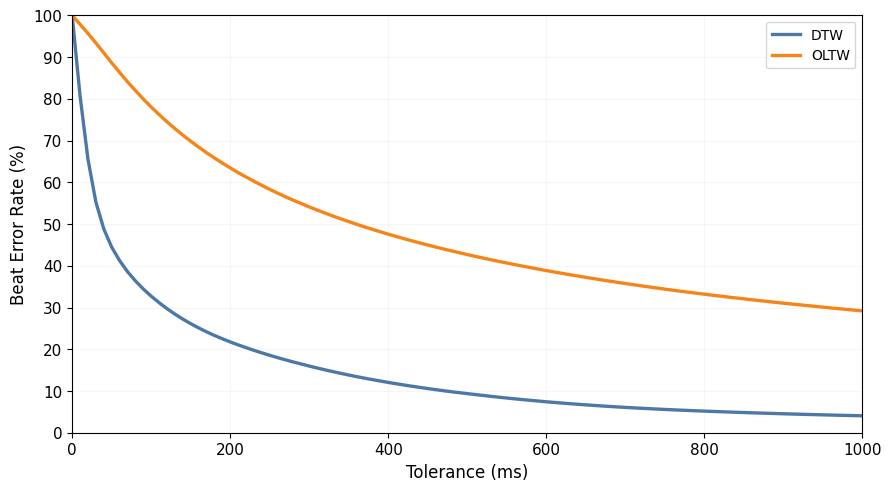

Saved figure to: /home/diego/School/SP26/E207_project/outputs/figures/paper_style_method_comparison_curves.png


In [17]:
curve_frames = []
for experiment_name, meta in EXPERIMENTS.items():
    frame = pd.read_csv(meta["path"]).copy()
    frame["display_name"] = meta["label"]
    frame["color"] = meta["color"]
    curve_frames.append(frame)

curve_frame = pd.concat(curve_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
for label in method_order:
    method_frame = curve_frame.loc[curve_frame["display_name"] == label].sort_values("tolerance_s")
    color = method_frame["color"].iloc[0]
    ax.plot(
        method_frame["tolerance_s"] * 1000.0,
        method_frame["error_rate"] * 100.0,
        label=label,
        color=color,
        linewidth=2.4,
    )

ax.set_xlabel("Tolerance (ms)")
ax.set_ylabel("Beat Error Rate (%)")
# ax.set_title("Continuous tolerance-curve comparison")
ax.set_xlim(0, curve_frame["tolerance_s"].max() * 1000.0)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.grid(alpha=0.1)
ax.legend(loc="upper right", frameon=True)

curve_output = FIGURES_DIR / "paper_style_method_comparison_curves.png"
fig.savefig(curve_output, dpi=200, bbox_inches="tight")

plt.show()
print(f"Saved figure to: {curve_output}")

In [ ]:
full_pair_paths = {
    "OLTW": METRICS_DIR / "oltw_paper_test_pairs.csv",
    "OLTW-global": METRICS_DIR / "oltw_global_paper_test_pairs.csv",
}
full_error_paths = {
    "OLTW": METRICS_DIR / "oltw_paper_test_beat_errors.csv",
    "OLTW-global": METRICS_DIR / "oltw_global_paper_test_beat_errors.csv",
}

pair_frames = {label: pd.read_csv(path) for label, path in full_pair_paths.items()}
shared_pair_ids = sorted(
    set(pair_frames["OLTW"]["pair_id"]) & set(pair_frames["OLTW-global"]["pair_id"])
)

shared_error_frames = {}
for label, path in full_error_paths.items():
    frame = pd.read_csv(path)
    shared_error_frames[label] = frame.loc[frame["pair_id"].isin(shared_pair_ids)].copy()

rows = []
for tolerance_ms in TOLERANCES_MS:
    tolerance_s = tolerance_ms / 1000.0
    row = {"tolerance_ms": tolerance_ms}
    for label, frame in shared_error_frames.items():
        correct_rate = (frame["abs_error_s"] <= tolerance_s).mean()
        row[f"{label.lower()}_error_rate_pct"] = 100.0 * (1.0 - correct_rate)
    row["delta_pct_points_global_minus_oltw"] = (
        row["oltw-global_error_rate_pct"] - row["oltw_error_rate_pct"]
    )
    rows.append(row)

shared_delta_table = pd.DataFrame(rows).round(4)

print(f"OLTW full-run pairs: {pair_frames['OLTW']['pair_id'].nunique()}")
print(f"OLTW-global full-run pairs: {pair_frames['OLTW-global']['pair_id'].nunique()}")
print(f"Shared pairs used for comparison: {len(shared_pair_ids)}")
print(f"Shared OLTW beat predictions: {len(shared_error_frames['OLTW'])}")
print(f"Shared OLTW-global beat predictions: {len(shared_error_frames['OLTW-global'])}")

shared_delta_table